# 06 — ResNet50 (transfer learning)

**Pipeline** (shared across all six CNNs):

- **Input:** lesion-cropped images from `X_all.npy` (448×448 storage,
  Otsu segmentation applied in 00_data_setup).
- **Loss:** Focal Loss (γ=2.0) with class-balanced α (Cui et al. 2019, β=0.999).
- **Sampler:** WeightedRandomSampler — every batch is approximately 50/50
  melanoma/non-melanoma despite the 1:8 dataset imbalance.
- **Augmentation (conservative, medical-grade):** RandomResizedCrop(0.85, 1.0)
  + HFlip + VFlip + Rotation(±15°) + mild ColorJitter
  (brightness/contrast=0.10, saturation=0.05, hue=0.02) + small RandomErasing.
  RandAugment, Mixup and CutMix are intentionally disabled because they would
  distort or replace the lesion pixels that the ABCD diagnostic rule depends on.
- **Optimizer:** AdamW (wd=1e-4) with discriminative LR (head 3e-4, backbone 3e-5).
- **Schedule:** linear warmup (3 epochs) → cosine annealing to 1e-6.
- **Stage 1** (head only, 3 epochs, lr=1e-3) → **Stage 2** (full backbone,
  up to 25 epochs, early stopping on val F1, patience=7).
- **EMA** of weights (decay=0.999) — validation, threshold selection and TTA
  all use EMA weights.
- **Test-time augmentation:** 8-way (identity, hflip, vflip, hvflip,
  rot90/180/270, hflip+rot90); probabilities averaged.
- **Threshold:** F1-maximising threshold tuned on validation, applied once on test.

**Disconnect-proof:** the best-val-F1 weights are persisted to
`MyDrive/melanoma/checkpoints/resnet50_best.pt` every time val F1 improves.
If the runtime dies, the recovery cell at the bottom of this notebook reloads
the checkpoint, runs threshold tuning + TTA evaluation, and saves outputs —
no retraining required.

In [1]:
# --- Colab setup: ensure the project is on sys.path, mount Drive, load config ---
import os, sys, subprocess
from pathlib import Path

# Either the project is already on disk (uploaded zip / mounted Drive) or we
# clone it from GitHub. We never destroy local changes.
REPO_URL = "https://github.com/zkoymen/melanoma-detection-ham10000.git"
CANDIDATE_PATHS = [
    Path.cwd(),
    Path("/content/melanoma-detection-ham10000"),
    Path("/content/drive/MyDrive/melanoma-detection-ham10000"),
]

project_root = None
for p in CANDIDATE_PATHS:
    if (p / "src").exists() and (p / "config.py").exists():
        project_root = p
        break

if project_root is None:
    project_root = Path("/content/melanoma-detection-ham10000")
    subprocess.run(["git", "clone", REPO_URL, str(project_root)], check=True)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Mount Drive (silently re-uses an existing mount on re-run)
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except (ImportError, ModuleNotFoundError):
    pass

import config
config.ensure_drive_dirs()
print("Project root:", project_root)
print("Drive root  :", config.DRIVE_ROOT)
print("Data dir    :", config.DATA_DIR)
print("Results dir :", config.RESULTS_DIR)

Mounted at /content/drive
Project root: /content/melanoma-detection-ham10000
Drive root  : /content/drive/MyDrive/melanoma
Data dir    : /content/drive/MyDrive/melanoma/data
Results dir : /content/drive/MyDrive/melanoma/results


In [2]:
import random, numpy as np, torch
random.seed(config.SEED); np.random.seed(config.SEED); torch.manual_seed(config.SEED)
torch.cuda.manual_seed_all(config.SEED)

In [3]:
!pip install --quiet timm 2>&1 | tail -n 1

In [4]:
# --- Architecture configuration ---
ARCH = "resnet50"
INPUT_SIZE = config.ARCH_CONFIG[ARCH]["input_size"]
BATCH_SIZE = config.ARCH_CONFIG[ARCH]["batch_size"]
print(f"Architecture: {ARCH}  input={INPUT_SIZE}  batch_size={BATCH_SIZE}")

Architecture: resnet50  input=320  batch_size=32


In [5]:
# --- Build datasets / dataloaders (data auto-cached to /content/local_data) ---
import numpy as np, torch
from torch.utils.data import DataLoader
from src.data import (load_arrays_balanced, HAMDataset,
                      make_train_transform_strong, make_eval_transform)
from src.training import make_weighted_sampler

X, y, ids, idx_train, idx_val, idx_test = load_arrays_balanced(config.DATA_DIR)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, "  X:", X.shape)

train_tf = make_train_transform_strong(
    INPUT_SIZE,
    rotation_deg=config.AUG_ROTATION_DEG,
    brightness=config.AUG_COLOR_BRIGHTNESS,
    contrast=config.AUG_COLOR_CONTRAST,
    saturation=config.AUG_COLOR_SATURATION,
    hue=config.AUG_COLOR_HUE,
    crop_scale_min=config.AUG_CROP_SCALE_MIN,
    crop_scale_max=config.AUG_CROP_SCALE_MAX,
    erasing_p=config.AUG_RANDOM_ERASING_P,
    erasing_scale=config.AUG_RANDOM_ERASING_SCALE,
)
eval_tf  = make_eval_transform(INPUT_SIZE)

train_ds = HAMDataset(X, y, idx_train, train_tf)
val_ds   = HAMDataset(X, y, idx_val,   eval_tf)
test_ds  = HAMDataset(X, y, idx_test,  eval_tf)

sampler = make_weighted_sampler(y[idx_train]) if config.USE_WEIGHTED_SAMPLER else None

train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE,
                      sampler=sampler, shuffle=(sampler is None),
                      num_workers=2, pin_memory=True, drop_last=True)
val_ld   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)
test_ld  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)
print(f"Batches: train={len(train_ld)}  val={len(val_ld)}  test={len(test_ld)}")

  copying X_combined.npy (1696.5 MB) Drive -> local SSD
  copying y_combined.npy (0.1 MB) Drive -> local SSD
  copying ids_combined.npy (0.2 MB) Drive -> local SSD
  copying source_combined.npy (0.1 MB) Drive -> local SSD
  copying lesion_combined.npy (0.2 MB) Drive -> local SSD
  copying idx_train_bal.npy (0.1 MB) Drive -> local SSD
  copying idx_val_bal.npy (0.0 MB) Drive -> local SSD
  copying idx_test_bal.npy (0.0 MB) Drive -> local SSD
Device: cuda   X: (11270, 224, 224, 3)
Batches: train=245  val=53  test=54


In [6]:
# --- Build model ---
from src.models import (BUILDERS, freeze_backbone, unfreeze_all,
                        trainable_params, discriminative_param_groups,
                        gradcam_target_layer)

model = BUILDERS[ARCH](num_classes=2, pretrained=True).to(device)
freeze_backbone(model)
print(f"Stage-1 trainable params: {trainable_params(model):,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s]


Stage-1 trainable params: 4,098


In [7]:
# --- Focal loss (class-balanced alpha) ---
from src.training import build_focal_loss
criterion = build_focal_loss(y[idx_train],
                             gamma=config.FOCAL_GAMMA,
                             beta=config.FOCAL_BETA,
                             device=device)
print(f"Focal loss: gamma={config.FOCAL_GAMMA}  beta={config.FOCAL_BETA}")
print(f"Class-balanced alpha: {criterion.alpha.cpu().numpy()}")

Focal loss: gamma=2.0  beta=0.999
Class-balanced alpha: [0.9998196 1.0001805]


In [8]:
# --- Stage 1: head only ---
import time, torch
from src.training import train_loop_v2, EpochLog, EMA, WarmupCosineSchedule

CHECKPOINT_PATH = config.CHECKPOINT_DIR / f"{ARCH}_best.pt"
print("Best weights -> ", CHECKPOINT_PATH)

# EMA shadow tracks the live model from the start
ema = EMA(model, decay=config.CNN_EMA_DECAY)

opt = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=config.CNN_HEAD_LR, weight_decay=config.CNN_WEIGHT_DECAY,
)
log = EpochLog()
t0 = time.time()
log = train_loop_v2(
    model, train_ld, val_ld, criterion, opt, device,
    epochs=config.CNN_HEAD_EPOCHS,
    num_classes=2,
    ema=ema,
    # No mixup/cutmix in stage 1 — head needs clean signal
    mixup_alpha=0.0, cutmix_alpha=0.0, mixup_prob=0.0, cutmix_prob=0.0,
    log=log, checkpoint_path=CHECKPOINT_PATH,
)

Best weights ->  /content/drive/MyDrive/melanoma/checkpoints/resnet50_best.pt
epoch 01  lr=1.00e-03  tr_loss=0.1468  val_loss=0.6798  val_f1=0.5569  (97.8s)
  -> checkpoint saved to /content/drive/MyDrive/melanoma/checkpoints/resnet50_best.pt
epoch 02  lr=1.00e-03  tr_loss=0.1402  val_loss=0.6585  val_f1=0.6248  (98.1s)
  -> checkpoint saved to /content/drive/MyDrive/melanoma/checkpoints/resnet50_best.pt
epoch 03  lr=1.00e-03  tr_loss=0.1406  val_loss=0.6408  val_f1=0.6324  (95.0s)
  -> checkpoint saved to /content/drive/MyDrive/melanoma/checkpoints/resnet50_best.pt


In [9]:
# --- Stage 2: unfreeze full backbone with discriminative LR + warmup-cosine ---
unfreeze_all(model)
print(f"Stage-2 trainable params: {trainable_params(model):,}")

groups = discriminative_param_groups(
    model,
    head_lr=config.CNN_FT_LR_HEAD,
    backbone_lr=config.CNN_FT_LR_BACKBONE,
    weight_decay=config.CNN_WEIGHT_DECAY,
)
opt = torch.optim.AdamW(groups)
sched = WarmupCosineSchedule(
    opt,
    warmup_epochs=config.CNN_WARMUP_EPOCHS,
    total_epochs=config.CNN_FT_EPOCHS,
    base_lrs=[config.CNN_FT_LR_BACKBONE, config.CNN_FT_LR_HEAD],
    min_lr=1e-6,
)

log = train_loop_v2(
    model, train_ld, val_ld, criterion, opt, device,
    epochs=config.CNN_FT_EPOCHS,
    num_classes=2,
    scheduler=sched, ema=ema,
    mixup_alpha=config.MIXUP_ALPHA, cutmix_alpha=config.CUTMIX_ALPHA,
    mixup_prob=config.MIXUP_PROB, cutmix_prob=config.CUTMIX_PROB,
    early_stop_patience=config.CNN_EARLY_STOP_PATIENCE,
    log=log, checkpoint_path=CHECKPOINT_PATH,
)
train_time = time.time() - t0
print(f"Total training time: {train_time:.1f}s. Best weights at {CHECKPOINT_PATH}")

Stage-2 trainable params: 23,512,130
epoch 01  lr=1.00e-05  tr_loss=0.1374  val_loss=0.6332  val_f1=0.6542  (96.4s)
  -> checkpoint saved to /content/drive/MyDrive/melanoma/checkpoints/resnet50_best.pt
epoch 02  lr=2.00e-05  tr_loss=0.1322  val_loss=0.6218  val_f1=0.6739  (96.4s)
  -> checkpoint saved to /content/drive/MyDrive/melanoma/checkpoints/resnet50_best.pt
epoch 03  lr=3.00e-05  tr_loss=0.1279  val_loss=0.6068  val_f1=0.6932  (96.2s)
  -> checkpoint saved to /content/drive/MyDrive/melanoma/checkpoints/resnet50_best.pt
epoch 04  lr=3.00e-05  tr_loss=0.1226  val_loss=0.5869  val_f1=0.7142  (95.9s)
  -> checkpoint saved to /content/drive/MyDrive/melanoma/checkpoints/resnet50_best.pt
epoch 05  lr=2.99e-05  tr_loss=0.1177  val_loss=0.5687  val_f1=0.7342  (96.0s)
  -> checkpoint saved to /content/drive/MyDrive/melanoma/checkpoints/resnet50_best.pt
epoch 06  lr=2.94e-05  tr_loss=0.1115  val_loss=0.5506  val_f1=0.7453  (96.2s)
  -> checkpoint saved to /content/drive/MyDrive/melanoma/ch

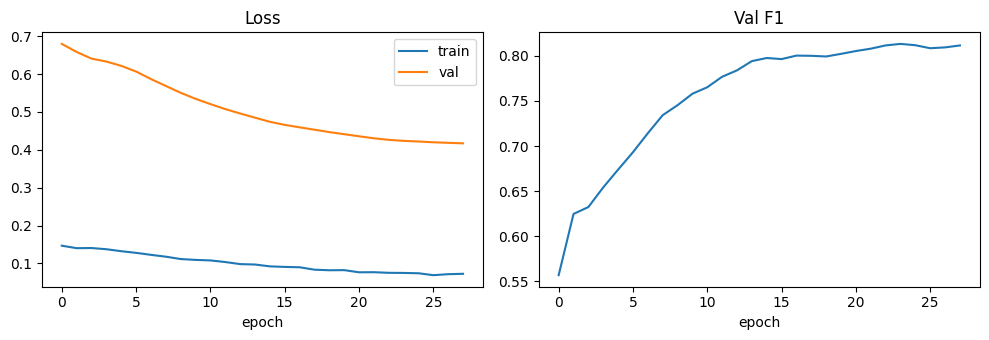

In [10]:
# --- Plot loss / F1 curves and save the raw arrays for the aggregation overlay ---
import numpy as np, matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(log.train_loss, label="train"); ax[0].plot(log.val_loss, label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(log.val_f1); ax[1].set_title("Val F1"); ax[1].set_xlabel("epoch")
fig.tight_layout()
fig.savefig(config.RESULTS_DIR / f"{ARCH}_curves.png", dpi=120)
np.savez(config.RESULTS_DIR / f"{ARCH}_curves.npz",
         train_loss=np.array(log.train_loss),
         val_loss=np.array(log.val_loss),
         val_f1=np.array(log.val_f1))
plt.show()

In [11]:
# --- Apply EMA weights for evaluation ---
ema.apply_shadow(model)

In [12]:
# --- Single-pass val probabilities (for threshold tuning + 'no TTA' ablation) ---
import numpy as np
from src.training import predict, tune_threshold

y_val_true, _, y_val_prob = predict(model, val_ld, device)
best_t, best_val_f1 = tune_threshold(y_val_true, y_val_prob)
print(f"Threshold (no TTA) best on val: t={best_t:.3f}  F1={best_val_f1:.4f}")

Threshold (no TTA) best on val: t=0.445  F1=0.8251


In [13]:
# --- TTA val probabilities + threshold ---
from src.training import tta_predict
y_val_true_tta, y_val_prob_tta = tta_predict(model, val_ld, device, config.TTA_TRANSFORMS)
best_t_tta, best_val_f1_tta = tune_threshold(y_val_true_tta, y_val_prob_tta)
print(f"Threshold (TTA)   best on val: t={best_t_tta:.3f}  F1={best_val_f1_tta:.4f}")

Threshold (TTA)   best on val: t=0.395  F1=0.8266


In [14]:
# --- Test evaluation: single-pass + TTA, with both thresholds ---
import time
import numpy as np

# Single-pass test
t0 = time.time()
y_test_true, _, y_test_prob = predict(model, test_ld, device)
inf_ms_single = (time.time() - t0) * 1000.0 / len(y_test_true)

# TTA test
t0 = time.time()
y_test_true2, y_test_prob_tta = tta_predict(model, test_ld, device, config.TTA_TRANSFORMS)
inf_ms_tta = (time.time() - t0) * 1000.0 / len(y_test_true2)
assert np.array_equal(y_test_true, y_test_true2)

y_pred_single = (y_test_prob > best_t).astype(int)
y_pred_tta    = (y_test_prob_tta > best_t_tta).astype(int)

print(f"Single-pass inf: {inf_ms_single:.2f} ms/img")
print(f"TTA (8-way) inf: {inf_ms_tta:.2f} ms/img")

Single-pass inf: 2.02 ms/img
TTA (8-way) inf: 5.80 ms/img


In [15]:
# --- Save standardized outputs (TTA result is the headline, but both columns persist) ---
import pandas as pd
from src.evaluation import save_standard_outputs, compute_metrics

# Headline metrics use TTA + tuned threshold
hp = dict(
    arch=ARCH,
    input_size=int(INPUT_SIZE),
    batch_size=int(BATCH_SIZE),
    head_lr=config.CNN_HEAD_LR,
    head_epochs=config.CNN_HEAD_EPOCHS,
    ft_lr_head=config.CNN_FT_LR_HEAD,
    ft_lr_backbone=config.CNN_FT_LR_BACKBONE,
    ft_epochs=config.CNN_FT_EPOCHS,
    warmup_epochs=config.CNN_WARMUP_EPOCHS,
    early_stop_patience=config.CNN_EARLY_STOP_PATIENCE,
    weight_decay=config.CNN_WEIGHT_DECAY,
    ema_decay=config.CNN_EMA_DECAY,
    focal_gamma=config.FOCAL_GAMMA,
    focal_beta=config.FOCAL_BETA,
    weighted_sampler=bool(config.USE_WEIGHTED_SAMPLER),
    augmentation=("RandomResizedCrop(0.85,1.0)+HFlip+VFlip+"
                  f"Rotation({config.AUG_ROTATION_DEG})+mildColorJitter+"
                  f"RandomErasing(p={config.AUG_RANDOM_ERASING_P}); "
                  "no Mixup/CutMix/RandAugment"),
    stored_image_size=int(config.IMG_SIZE),
    segmentation="Otsu(LAB-L invert)+morph close/open+largest CC+15% margin crop",
    split="lesion-grouped stratified 70/15/15",
    decision_threshold_tta=best_t_tta,
    decision_threshold_single=best_t,
    threshold_selection="argmax F1 on validation set",
    tta_transforms=list(config.TTA_TRANSFORMS),
)

metrics = save_standard_outputs(
    method_name=ARCH,
    results_dir=config.RESULTS_DIR,
    y_true=y_test_true,
    y_pred=y_pred_tta,         # headline = TTA + tuned threshold
    y_prob=y_test_prob_tta,    # headline probability = TTA-averaged
    ids=ids[idx_test],
    hyperparameters=hp,
    train_time_sec=train_time,
    inference_time_per_image_ms=inf_ms_tta,
)

# Also save the rich TEST predictions CSV with both single and TTA columns
# (the aggregation notebook needs this to compute the TTA ablation row).
pd.DataFrame({
    "image_id": ids[idx_test],
    "y_true":   y_test_true,
    "y_pred_single": y_pred_single,
    "y_prob_single": y_test_prob,
    "y_pred_tta":    y_pred_tta,
    "y_prob_tta":    y_test_prob_tta,
    "best_t_single": best_t,
    "best_t_tta":    best_t_tta,
}).to_csv(config.RESULTS_DIR / f"{ARCH}_predictions.csv", index=False)

# VAL predictions CSV — required by the ensemble (method 9) for threshold
# tuning on a held-out set. The aggregation notebook averages these
# probabilities across all 6 CNNs, sweeps thresholds on val, and applies
# the best threshold once on the test ensemble.
pd.DataFrame({
    "image_id": ids[idx_val],
    "y_true":   y_val_true,
    "y_prob_single": y_val_prob,
    "y_prob_tta":    y_val_prob_tta,
}).to_csv(config.RESULTS_DIR / f"{ARCH}_val_predictions.csv", index=False)

# Side-by-side diagnostic
m_single = compute_metrics(y_test_true, y_pred_single, y_test_prob)
m_tta    = compute_metrics(y_test_true, y_pred_tta,    y_test_prob_tta)
print("Single-pass test metrics:", {k: round(v, 4) for k, v in m_single.items()})
print("TTA-headline   test metrics:", {k: round(v, 4) for k, v in m_tta.items()})

Single-pass test metrics: {'accuracy': 0.798, 'precision': 0.7715, 'recall': 0.8469, 'f1': 0.8074, 'roc_auc': 0.8865}
TTA-headline   test metrics: {'accuracy': 0.7886, 'precision': 0.7379, 'recall': 0.8952, 'f1': 0.8089, 'roc_auc': 0.8931}


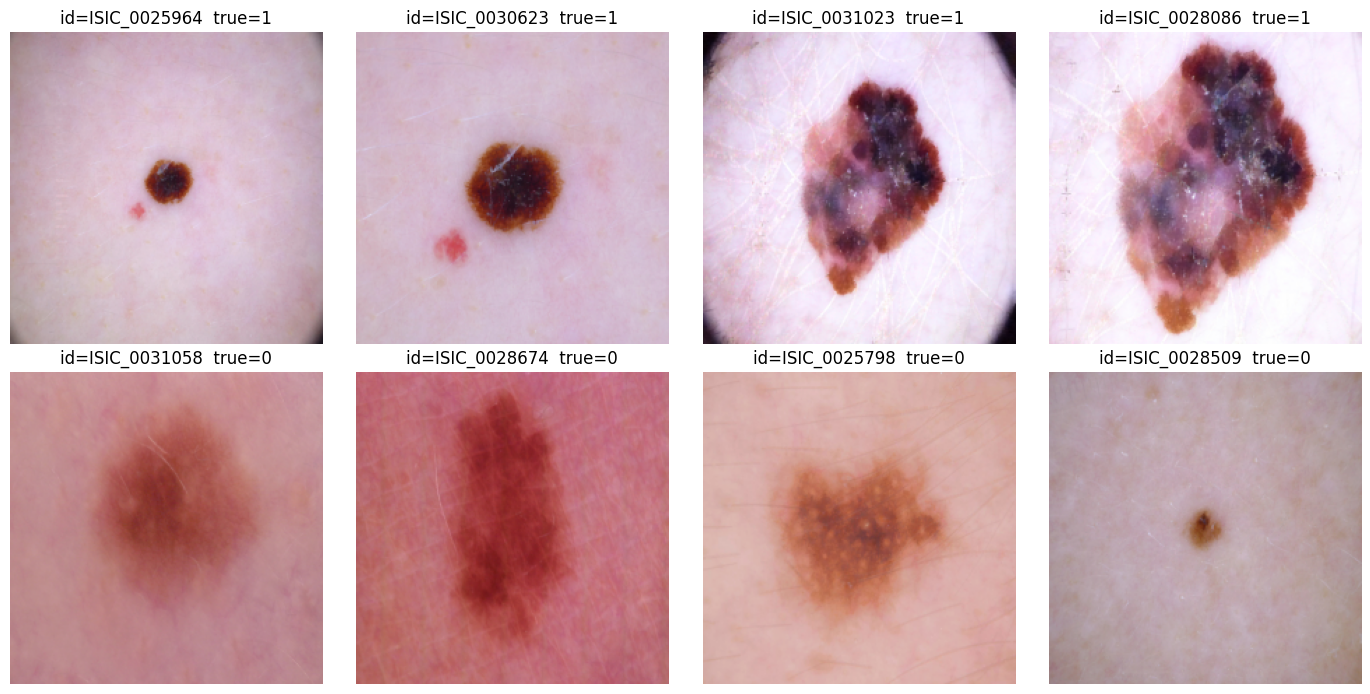

In [16]:
# --- Grad-CAM grid: 4 melanoma + 4 non-melanoma test images ---
import numpy as np, torch, matplotlib.pyplot as plt
from src.gradcam import GradCAM, overlay_heatmap

target_layer = gradcam_target_layer(model, ARCH)
cam = GradCAM(model, target_layer)
mel_idx    = idx_test[y[idx_test] == 1][:4]
nonmel_idx = idx_test[y[idx_test] == 0][:4]
chosen = list(mel_idx) + list(nonmel_idx)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, k in zip(axes.flat, chosen):
    img = X[k]
    t = eval_tf(img).unsqueeze(0).to(device)
    try:
        heat = cam(t, class_idx=int(y[k]))
        ax.imshow(overlay_heatmap(img, heat))
    except Exception:
        # Some attention archs (e.g. Swin) may not produce a valid CAM via
        # plain gradcam; fall back to showing the raw image.
        ax.imshow(img); ax.set_title(f"Grad-CAM N/A for {ARCH}")
    ax.set_title(f"id={ids[k]}  true={int(y[k])}")
    ax.axis("off")
cam.close()
fig.tight_layout()
fig.savefig(config.RESULTS_DIR / f"{ARCH}_gradcam_grid.png", dpi=120)
plt.show()

---
## Recovery cell (use only if the runtime disconnected during training)

If the cells above never finished but you saw at least one
`-> checkpoint saved` line during training, the best weights are at
`MyDrive/melanoma/checkpoints/resnet50_best.pt`. Run **only the recovery cell
below** on a fresh runtime (after re-running the preamble + dataset cells)
to finish evaluation without retraining.

In [17]:
# --- Recovery: load checkpoint, re-run threshold + TTA, save outputs ---
import torch, time, numpy as np, pandas as pd
from src.training import predict, tune_threshold, tta_predict
from src.evaluation import save_standard_outputs

CHECKPOINT_PATH = config.CHECKPOINT_DIR / f"{ARCH}_best.pt"
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()

y_val_true, _, y_val_prob = predict(model, val_ld, device)
best_t, _ = tune_threshold(y_val_true, y_val_prob)
y_val_true_tta, y_val_prob_tta = tta_predict(model, val_ld, device, config.TTA_TRANSFORMS)
best_t_tta, _ = tune_threshold(y_val_true_tta, y_val_prob_tta)

t0 = time.time()
y_test_true, _, y_test_prob = predict(model, test_ld, device)
inf_ms_single = (time.time() - t0) * 1000.0 / len(y_test_true)
t0 = time.time()
_, y_test_prob_tta = tta_predict(model, test_ld, device, config.TTA_TRANSFORMS)
inf_ms_tta = (time.time() - t0) * 1000.0 / len(y_test_true)

y_pred_tta = (y_test_prob_tta > best_t_tta).astype(int)
y_pred_single = (y_test_prob > best_t).astype(int)
metrics = save_standard_outputs(
    method_name=ARCH,
    results_dir=config.RESULTS_DIR,
    y_true=y_test_true, y_pred=y_pred_tta, y_prob=y_test_prob_tta,
    ids=ids[idx_test],
    hyperparameters={"recovered_from_checkpoint": True,
                     "decision_threshold_tta": best_t_tta,
                     "decision_threshold_single": best_t},
    train_time_sec=0.0,
    inference_time_per_image_ms=inf_ms_tta,
)

# Save the rich predictions CSVs (test + val) — same layout as the main
# pipeline cell so the aggregation notebook can read either source.
pd.DataFrame({
    "image_id": ids[idx_test],
    "y_true":   y_test_true,
    "y_pred_single": y_pred_single,
    "y_prob_single": y_test_prob,
    "y_pred_tta":    y_pred_tta,
    "y_prob_tta":    y_test_prob_tta,
    "best_t_single": best_t,
    "best_t_tta":    best_t_tta,
}).to_csv(config.RESULTS_DIR / f"{ARCH}_predictions.csv", index=False)
pd.DataFrame({
    "image_id": ids[idx_val],
    "y_true":   y_val_true,
    "y_prob_single": y_val_prob,
    "y_prob_tta":    y_val_prob_tta,
}).to_csv(config.RESULTS_DIR / f"{ARCH}_val_predictions.csv", index=False)
{k: round(v, 4) for k, v in metrics.items() if isinstance(v, (int, float))}

{'accuracy': 0.7803,
 'precision': 0.72,
 'recall': 0.9176,
 'f1': 0.8068,
 'roc_auc': 0.8915,
 'train_time_sec': 0.0,
 'inference_time_per_image_ms': 5.783}